In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
import os
import random

In [2]:
def transform(image):
    grayScale = cv.cvtColor( image, cv.COLOR_RGB2GRAY )
    kernel = cv.getStructuringElement(1,(17,17))
    blackhat = cv.morphologyEx(grayScale, cv.MORPH_BLACKHAT, kernel)
    ret,thresh2 = cv.threshold(blackhat,10,255,cv.THRESH_BINARY)
    image = cv.inpaint(image,thresh2,1,cv.INPAINT_TELEA)
    image_yuv = cv.cvtColor(image, cv.COLOR_RGB2YUV)
    image_yuv[:, :, 0] = cv.equalizeHist(image_yuv[:, :, 0])
    image_equalized = cv.cvtColor(image_yuv, cv.COLOR_YUV2RGB)
    return np.array(image_equalized)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomContrast(0.2),
])
def data_aug(img, h, w):
    img = np.array(img)/255
    augmented = data_augmentation([img])
    img = np.array(augmented[0])
    img = cv.resize(img, (h, w))
    return img

In [3]:
root = './train'
buckets = {}
images = []
labels = []
augmented = []
factor = {'akiec': 2, 'bcc': 1, 'df': 4, 'vasc': 3}

h, w = 150, 150
for img_name in os.listdir(root):
    class_img = img_name.split('_')[0]
    if class_img == 'nv': continue
    elif class_img in buckets: buckets[class_img]+=1
    else: buckets[class_img] = 0
    img = cv.imread(os.path.join(root,img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    image = cv.resize(img, (h, w))
    image = transform(image)
    transformed_image = np.array(image)/255
    images.append(transformed_image)
    labels.append(class_img)
    if class_img in factor:
        for _ in range(factor[class_img]):
            buckets[class_img] += 1
            augmented_img = data_aug(img, h, w)
            images.append(augmented_img)
            labels.append(class_img)
    # if class_img in ['df', 'bcc', 'akiec', 'vasc']:
    #     for _ in range(2):
    #         buckets[class_img] += 1
    #         augmented_img = data_augmentation(tf.expand_dims(img, 0))
    #         augmented.append(tf.squeeze(augmented_img, axis=0).numpy())
    #         labels.append(class_img)
    # if class_img in ['df', 'vasc']:
    #     for _ in range(1):
    #         buckets[class_img] += 1
    #         augmented_img = data_augmentation(tf.expand_dims(img, 0))
    #         augmented.append(tf.squeeze(augmented_img, axis=0).numpy())
    #         labels.append(class_img)
print(len(images))
print(len(labels))

5364
5364


<class 'numpy.ndarray'>
--------------------------------------------------
<class 'numpy.ndarray'>


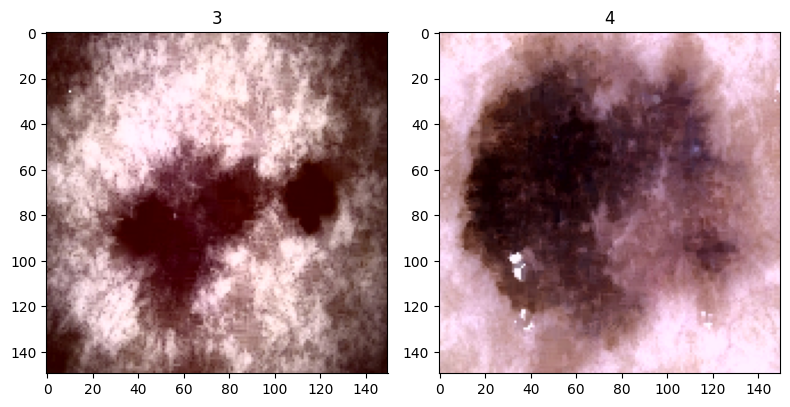

In [19]:
i = random.randint(0,len(images))
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[i])
plt.title(labels[i])

print(type(images[i]))
print('-'*50)
i = random.randint(0,len(images))

plt.subplot(1,2,2)
plt.imshow(images[i])
plt.title(labels[i])

print(type(images[i]))
plt.tight_layout()
plt.show()

In [20]:
print(buckets)

{'bkl': 1098, 'mel': 1112, 'df': 574, 'bcc': 1027, 'akiec': 980, 'vasc': 567}


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
images = np.array(images)
labels = np.array(labels)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, shuffle=True, random_state=42)

Text(0.5, 1.0, '2, test')

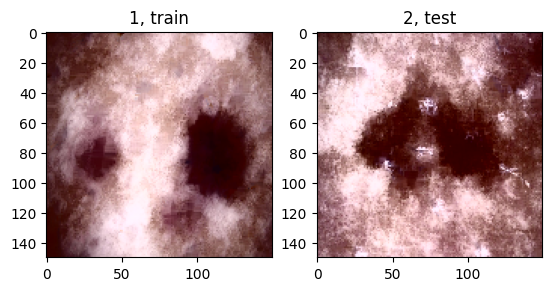

In [22]:
plt.subplot(1,2,1)
i = random.randint(0,len(X_train))
plt.imshow(X_train[i])
plt.title(f'{y_train[i]}, train')
i = random.randint(0,len(X_test))
plt.subplot(1,2,2)
plt.imshow(X_test[i])
plt.title(f'{y_test[i]}, test')

In [23]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(h, w, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 148, 148, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 72, 72, 64)        256       
 chNormalization)                                                
                                                      

In [26]:
# callbacks = [ tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
#             tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5') ]

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
135/135 [==============================] - 98s 723ms/step - loss: 2.0701 - accuracy: 0.3824 - val_loss: 4.1917 - val_accuracy: 0.1081
Epoch 2/20
135/135 [==============================] - 86s 635ms/step - loss: 1.2026 - accuracy: 0.5059 - val_loss: 3.4748 - val_accuracy: 0.2731
Epoch 3/20
135/135 [==============================] - 84s 620ms/step - loss: 1.0764 - accuracy: 0.5598 - val_loss: 1.8273 - val_accuracy: 0.3085
Epoch 4/20
135/135 [==============================] - 289s 2s/step - loss: 0.9423 - accuracy: 0.6185 - val_loss: 1.4274 - val_accuracy: 0.4585
Epoch 5/20
135/135 [==============================] - 86s 640ms/step - loss: 0.8369 - accuracy: 0.6619 - val_loss: 1.4164 - val_accuracy: 0.5033
Epoch 6/20
135/135 [==============================] - 83s 618ms/step - loss: 0.6868 - accuracy: 0.7248 - val_loss: 1.4039 - val_accuracy: 0.4958
Epoch 7/20
135/135 [==============================] - 88s 653ms/step - loss: 0.5941 - accuracy: 0.7700 - val_loss: 1.3640 - val_accu

In [27]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
acc = acc*100
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 51.445


34/34 [==============================] - 7s 207ms/step


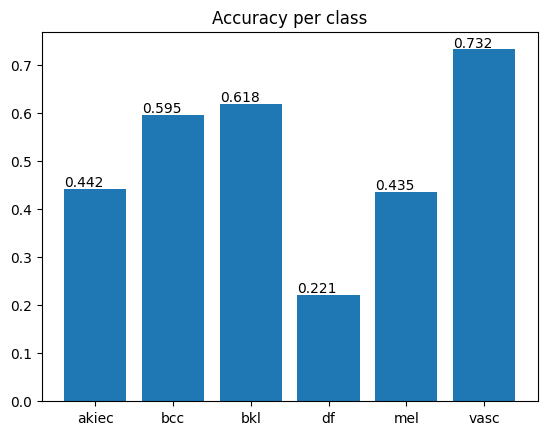

In [28]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)
# make a bargraph of accuracy per class
from sklearn.metrics import accuracy_score
acc_per_class = []
for i in range(6):
    acc_per_class.append(accuracy_score(y_test_label[y_test_label==i], y_pred_label[y_test_label==i]))

bars  = plt.bar(le.classes_, acc_per_class)
plt.title('Accuracy per class')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .005, round(yval,3))
plt.show()
# plt.bar(le.classes_, acc_per_class)
# plt.title('Accuracy per class')
# plt.show()

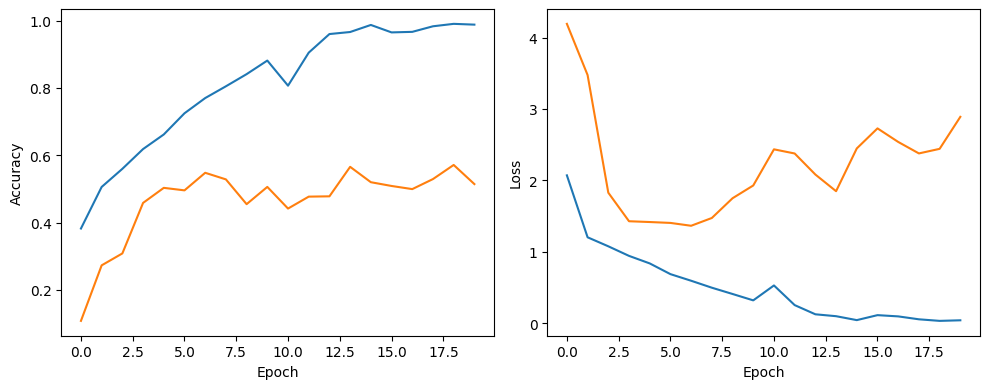

In [29]:
model.save('model_contrast.keras')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()